**1. Import Library**

In [327]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import zipfile
import matplotlib.pyplot as plt
import random

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve, mean_squared_error, mean_absolute_error, r2_score)
from imblearn.over_sampling import SMOTE
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score
from sklearn.metrics import roc_auc_score

**2. Upload Dataset**

In [46]:
from google.colab import files
uploaded = files.upload()

Saving olist_sellers_dataset.csv to olist_sellers_dataset (1).csv
Saving olist_geolocation_dataset.csv to olist_geolocation_dataset (1).csv
Saving olist_order_items_dataset.csv to olist_order_items_dataset (1).csv
Saving olist_order_payments_dataset.csv to olist_order_payments_dataset (1).csv
Saving olist_order_reviews_dataset.csv to olist_order_reviews_dataset (1).csv
Saving olist_orders_dataset.csv to olist_orders_dataset (1).csv
Saving olist_products_dataset.csv to olist_products_dataset (1).csv
Saving olist_customers_dataset.csv to olist_customers_dataset (1).csv
Saving product_category_name_translation.csv to product_category_name_translation (1).csv


**3. Read Dataset**

In [174]:
df = pd.read_csv('olist_orders_dataset.csv')
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


**4. Exploratory Data Analysis**

**Informasi Dataset**

In [175]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [176]:
date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

print("Date columns converted to datetime type.")
df.info()

Date columns converted to datetime type.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [177]:
df.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99281,97658,96476,99441
mean,2017-12-31 08:43:12.776581120,2017-12-31 18:35:24.098800128,2018-01-04 21:49:48.138278656,2018-01-14 12:09:19.035542272,2018-01-24 03:08:37.730111232
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00
25%,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.249999872,2017-09-25 22:07:22.249999872,2017-10-03 00:00:00
50%,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00
75%,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.249999872,2018-05-25 00:00:00
max,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00


**Statistik Descriptif**

In [178]:
df.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99281,97658,96476,99441
mean,2017-12-31 08:43:12.776581120,2017-12-31 18:35:24.098800128,2018-01-04 21:49:48.138278656,2018-01-14 12:09:19.035542272,2018-01-24 03:08:37.730111232
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-09-30 00:00:00
25%,2017-09-12 14:46:19,2017-09-12 23:24:16,2017-09-15 22:28:50.249999872,2017-09-25 22:07:22.249999872,2017-10-03 00:00:00
50%,2018-01-18 23:04:36,2018-01-19 11:36:13,2018-01-24 16:10:58,2018-02-02 19:28:10.500000,2018-02-15 00:00:00
75%,2018-05-04 15:42:16,2018-05-04 20:35:10,2018-05-08 13:37:45,2018-05-15 22:48:52.249999872,2018-05-25 00:00:00
max,2018-10-17 17:30:18,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-11-12 00:00:00


**Feature Engineering for Correlation Analysis**

In [179]:
datetime_cols_to_process = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in datetime_cols_to_process:
    if col in df.columns:
        df[f'{col}_year'] = df[col].dt.year
        df[f'{col}_month'] = df[col].dt.month
        df[f'{col}_day'] = df[col].dt.day
        df[f'{col}_hour'] = df[col].dt.hour
        df[f'{col}_dayofweek'] = df[col].dt.dayofweek
df = df.drop(columns=datetime_cols_to_process, errors='ignore')

identifier_cols_to_drop = ['order_id', 'customer_id']
df = df.drop(columns=identifier_cols_to_drop, errors='ignore')

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
if 'order_status' in df.columns and df['order_status'].dtype == 'object':
    df['order_status'] = le.fit_transform(df['order_status'].astype(str))

print("DataFrame prepared for correlation analysis.")
df.info()

DataFrame prepared for correlation analysis.
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 26 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   order_status                             99441 non-null  int64  
 1   order_purchase_timestamp_year            99441 non-null  int32  
 2   order_purchase_timestamp_month           99441 non-null  int32  
 3   order_purchase_timestamp_day             99441 non-null  int32  
 4   order_purchase_timestamp_hour            99441 non-null  int32  
 5   order_purchase_timestamp_dayofweek       99441 non-null  int32  
 6   order_approved_at_year                   99281 non-null  float64
 7   order_approved_at_month                  99281 non-null  float64
 8   order_approved_at_day                    99281 non-null  float64
 9   order_approved_at_hour                   99281 non-null  float64
 10  o

**Missing Value**

In [180]:
df.isnull().sum()

,0
order_status,0
order_purchase_timestamp_year,0
order_purchase_timestamp_month,0
order_purchase_timestamp_day,0
order_purchase_timestamp_hour,0
order_purchase_timestamp_dayofweek,0
order_approved_at_year,160
order_approved_at_month,160
order_approved_at_day,160
order_approved_at_hour,160


Visualisasi

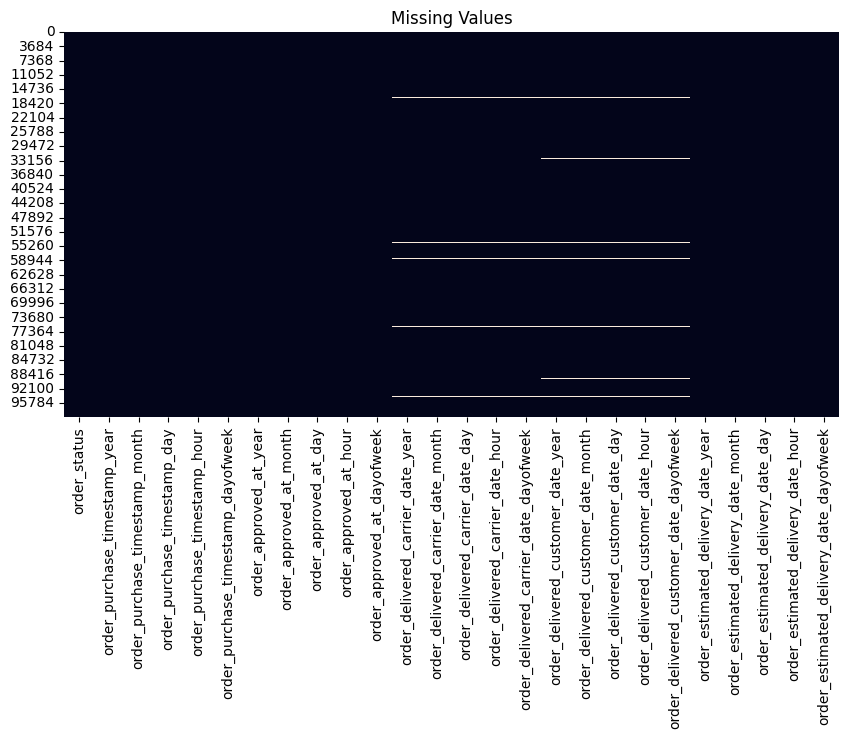

In [181]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values")
plt.show()

**Distribusi Target**

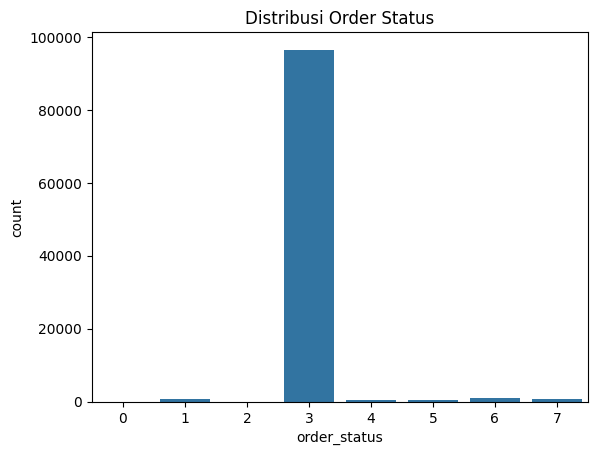

In [182]:
sns.countplot(data=df, x='order_status')

plt.title("Distribusi Order Status")
plt.show()

**Feature Correlation Matrix**

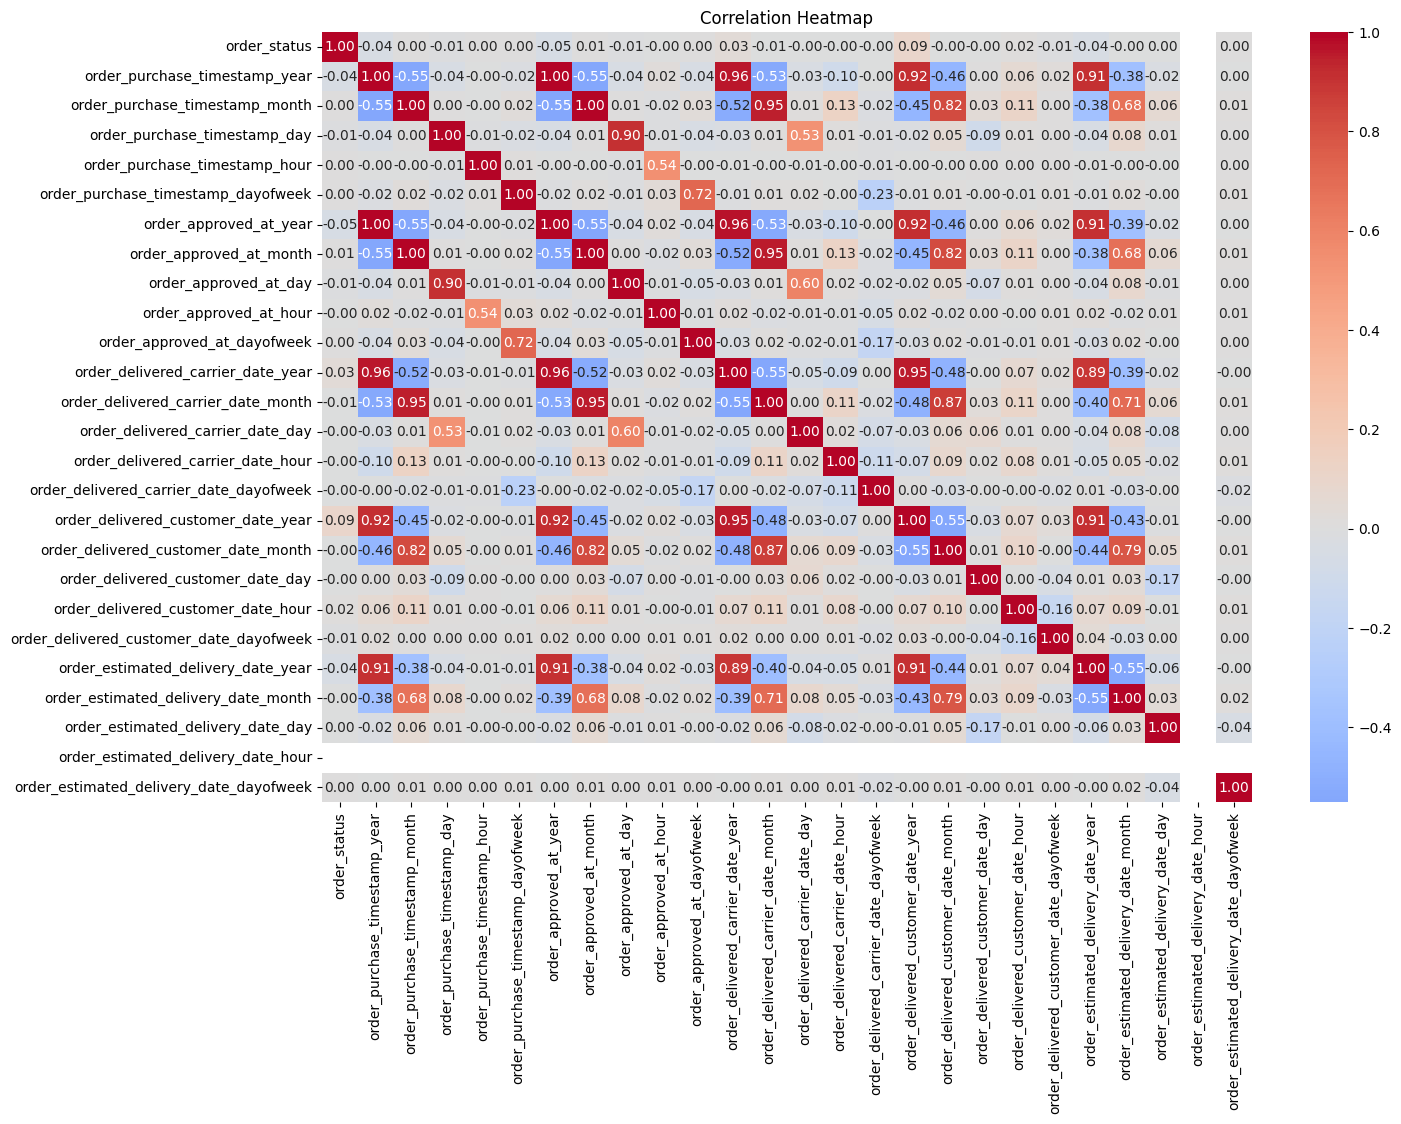

In [183]:
df_corr = df.copy()

date_columns = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_columns:
    if col in df_corr.columns:
        df_corr[col] = pd.to_datetime(df_corr[col], errors='coerce')

datetime_cols_to_process = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in datetime_cols_to_process:
    if col in df_corr.columns:
        df_corr[f'{col}_year'] = df_corr[col].dt.year
        df_corr[f'{col}_month'] = df_corr[col].dt.month
        df_corr[f'{col}_day'] = df_corr[col].dt.day
        df_corr[f'{col}_hour'] = df_corr[col].dt.hour
        df_corr[f'{col}_dayofweek'] = df_corr[col].dt.dayofweek
df_corr = df_corr.drop(columns=datetime_cols_to_process, errors='ignore')

identifier_cols_to_drop = ['order_id', 'customer_id']
df_corr = df_corr.drop(columns=identifier_cols_to_drop, errors='ignore')

le = LabelEncoder()
if 'order_status' in df_corr.columns and df_corr['order_status'].dtype == 'object':
    df_corr['order_status'] = le.fit_transform(df_corr['order_status'].astype(str))

for col in df_corr.select_dtypes(include=np.number).columns:
    df_corr[col] = df_corr[col].fillna(df_corr[col].median())

numeric_df = df_corr.select_dtypes(include=np.number)

if not numeric_df.empty and len(numeric_df.columns) > 1:
    corr_matrix = numeric_df.corr()
    plt.figure(figsize=(15,10))
    sns.heatmap(corr_matrix,annot=True, fmt='.2f', cmap='coolwarm', center=0)
    plt.title('Correlation Heatmap')
    plt.show()
else:
    print("DataFrame does not contain enough numerical columns for correlation after preprocessing.")
    print(df_corr.info())

**Splitting Data**

In [204]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

**5. Data Preprocessing**

**Missing Value**

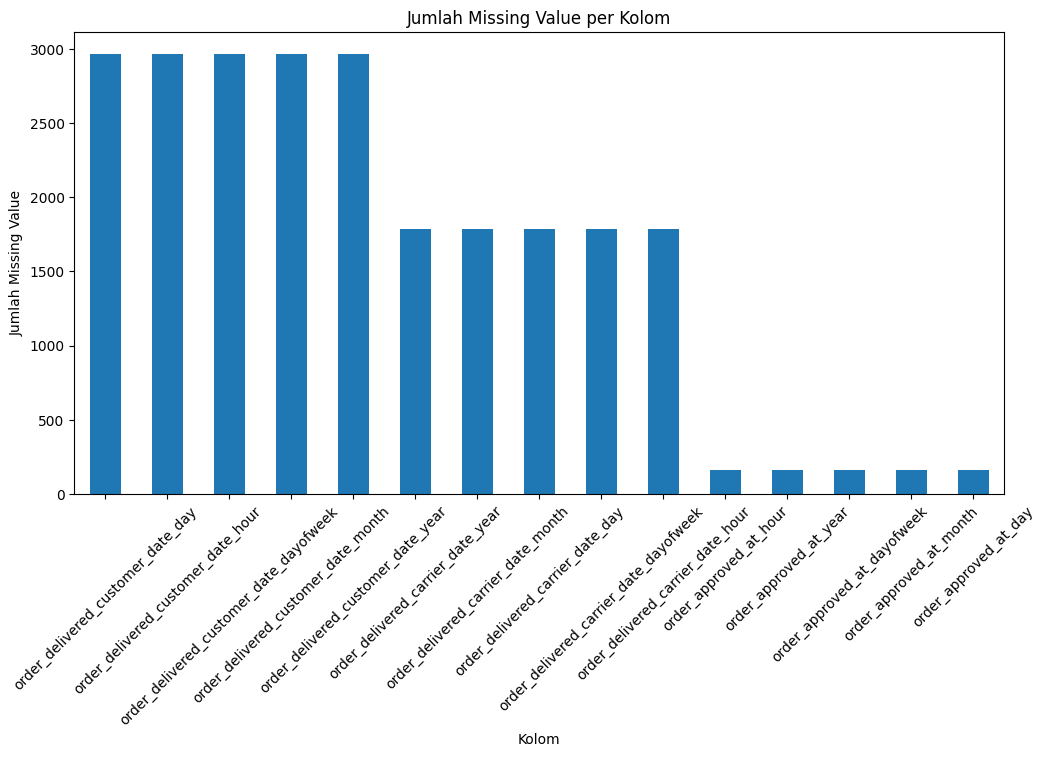

In [184]:
missing = df.isnull().sum()
missing = missing[missing > 0]

plt.figure(figsize=(12,6))
missing.sort_values(ascending=False).plot(kind='bar')
plt.title('Jumlah Missing Value per Kolom')
plt.xlabel('Kolom')
plt.ylabel('Jumlah Missing Value')
plt.xticks(rotation=45)
plt.show()

**Encoding**

In [185]:
le = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col].astype(str))

**Feature dan Target**

In [186]:
X = df.drop('order_status', axis=1)
y = df['order_status']

datetime_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

identifier_cols = ['order_id', 'customer_id']

X = X.drop(columns=datetime_cols + identifier_cols, errors='ignore')

**Train Test Split**

In [187]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [188]:
X

,order_purchase_timestamp_year,order_purchase_timestamp_month,order_purchase_timestamp_day,order_purchase_timestamp_hour,order_purchase_timestamp_dayofweek,order_approved_at_year,order_approved_at_month,order_approved_at_day,order_approved_at_hour,order_approved_at_dayofweek,...,order_delivered_customer_date_year,order_delivered_customer_date_month,order_delivered_customer_date_day,order_delivered_customer_date_hour,order_delivered_customer_date_dayofweek,order_estimated_delivery_date_year,order_estimated_delivery_date_month,order_estimated_delivery_date_day,order_estimated_delivery_date_hour,order_estimated_delivery_date_dayofweek
0,2017,10,2,10,0,2017.0,10.0,2.0,11.0,0.0,...,2017.0,10.0,10.0,21.0,1.0,2017,10,18,0,2
1,2018,7,24,20,1,2018.0,7.0,26.0,3.0,3.0,...,2018.0,8.0,7.0,15.0,1.0,2018,8,13,0,0
2,2018,8,8,8,2,2018.0,8.0,8.0,8.0,2.0,...,2018.0,8.0,17.0,18.0,4.0,2018,9,4,0,1
3,2017,11,18,19,5,2017.0,11.0,18.0,19.0,5.0,...,2017.0,12.0,2.0,0.0,5.0,2017,12,15,0,4
4,2018,2,13,21,1,2018.0,2.0,13.0,22.0,1.0,...,2018.0,2.0,16.0,18.0,4.0,2018,2,26,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99436,2017,3,9,9,3,2017.0,3.0,9.0,9.0,3.0,...,2017.0,3.0,17.0,15.0,4.0,2017,3,28,0,1
99437,2018,2,6,12,1,2018.0,2.0,6.0,13.0,1.0,...,2018.0,2.0,28.0,17.0,2.0,2018,3,2,0,4
99438,2017,8,27,14,6,2017.0,8.0,27.0,15.0,6.0,...,2017.0,9.0,21.0,11.0,3.0,2017,9,27,0,2
99439,2018,1,8,21,0,2018.0,1.0,8.0,21.0,0.0,...,2018.0,1.0,25.0,23.0,3.0,2018,2,15,0,3


In [189]:
y

,order_status
0,3
1,3
2,3
3,3
4,3
...,...
99436,3
99437,3
99438,3
99439,3


**Normalisasi**

In [244]:
X_train_numeric = X_train.select_dtypes(include=['number']).copy()
X_test_numeric = X_test.select_dtypes(include=['number']).copy()

for col in X_train_numeric.columns:
    if X_train_numeric[col].isnull().any():
        median_val = X_train_numeric[col].median()
        X_train_numeric.loc[:, col] = X_train_numeric[col].fillna(median_val)
for col in X_test_numeric.columns:
    if X_test_numeric[col].isnull().any():
        median_val = X_test_numeric[col].median()
        X_test_numeric.loc[:, col] = X_test_numeric[col].fillna(median_val)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_numeric)
X_test_scaled = scaler.transform(X_test_numeric)

**SMOTE**

In [195]:
for col in X_train.select_dtypes(include=np.number).columns:
    if X_train[col].isnull().any():
        median_val = X_train[col].median()
        X_train[col].fillna(median_val, inplace=True)
    if X_test[col].isnull().any():
        median_val = X_test[col].median()
        X_test[col].fillna(median_val, inplace=True)

print("Missing values in X_train filled.")
print("Missing values in X_test filled.")

print("\nMissing values in X_train after filling:")
print(X_train.isnull().sum().sum())
print("\nMissing values in X_test after filling:")
print(X_test.isnull().sum().sum())

Missing values in X_train filled.
Missing values in X_test filled.

Missing values in X_train after filling:
0

Missing values in X_test after filling:
0


**6. Model Decision Tree**

**Decision Tree Pipeline Creation**

In [199]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)

**DT-C Parameter Grid**

In [206]:
param_grid = {
    'max_depth':[3,5,10],
    'min_samples_split':[2,5,10]}

**DT-C Hyperparameter Tuning**

In [222]:
from sklearn.model_selection import GridSearchCV
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy')
dt_grid.fit(X_train, y_train)

best_dt = dt_grid.best_estimator_
print(f"Best parameters: {dt_grid.best_params_}")
print(f"Best cross-validation accuracy: {dt_grid.best_score_:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_split.py:805: UserWarning: The least populated class in y has only 2 members, which is less than n_splits=5.
  warnings.warn(


Best parameters: {'max_depth': 5, 'min_samples_split': 10}
Best cross-validation accuracy: 0.9894


**DT-C Data Test Evaluation**

In [223]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt, average='weighted', zero_division=0))
print("Recall:", recall_score(y_test, y_pred_dt, average='weighted', zero_division=0))
print("AUC:", roc_auc_score(y_test, y_prob_dt, multi_class='ovr', average='weighted', labels=unique_labels))

Accuracy: 0.9872794006737392
Precision: 0.9871817101090882
Recall: 0.9872794006737392
AUC: 0.9886991892078516


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


**Confusion Matrix**

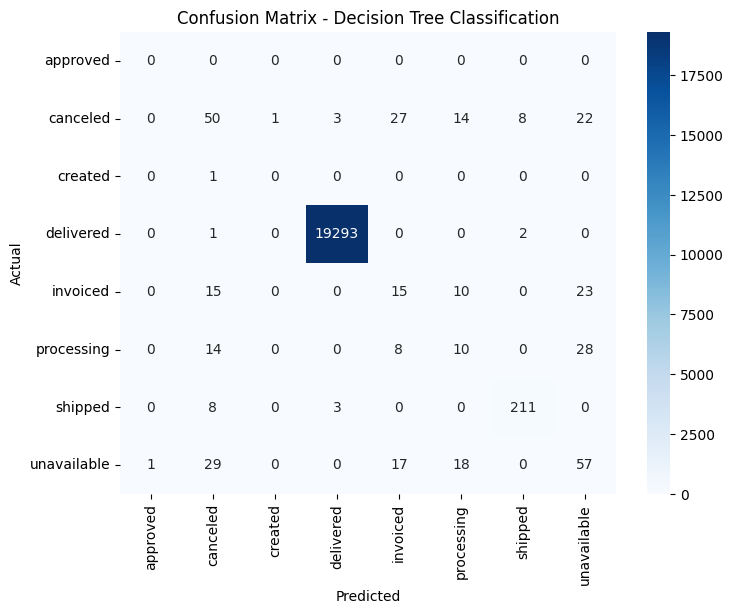

In [221]:
conf_matrix = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names_list, yticklabels=class_names_list)
plt.title("Confusion Matrix - Decision Tree Classification")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

**Decision Tree Visualization**

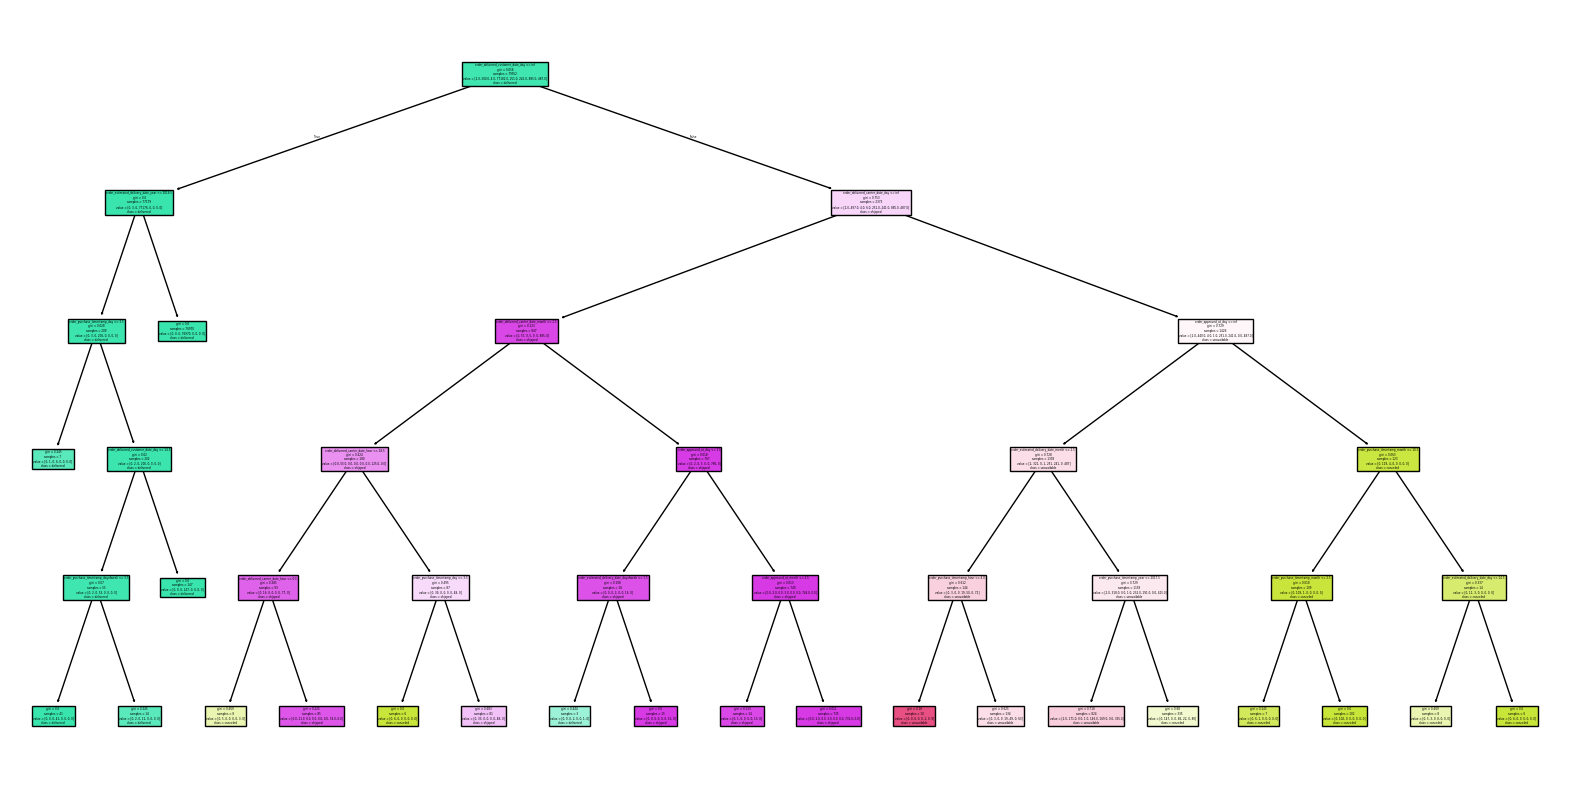

In [217]:
from sklearn.tree import plot_tree
class_names_list = ['approved', 'canceled', 'created', 'delivered', 'invoiced', 'processing', 'shipped', 'unavailable']

plt.figure(figsize=(20,10))
plot_tree(best_dt, filled=True, feature_names=X.columns, class_names=class_names_list)
plt.show()

In [271]:
from sklearn.metrics import accuracy_score
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print("Decision Tree Accuracy:", dt_accuracy)

Decision Tree Accuracy: 0.9872794006737392


Evaluasi DT

In [361]:
# For Decision Tree evaluation, we need to ensure y_test has integer labels.
# From the kernel state, y_test_ann contains correct integer labels for the test set.
# We will use y_test_ann as the true labels for DT evaluation to resolve the ValueError.
# The unique_labels should also be derived from these correct integer labels.
correct_y_test_dt = y_test_ann
dt_unique_labels = np.unique(correct_y_test_dt)

dt_accuracy = accuracy_score(correct_y_test_dt, y_pred_dt)
dt_precision = precision_score(correct_y_test_dt, y_pred_dt, average='weighted', zero_division=0)
dt_recall = recall_score(correct_y_test_dt, y_pred_dt, average='weighted', zero_division=0)
dt_f1 = f1_score(correct_y_test_dt, y_pred_dt, average='weighted', zero_division=0)
# y_prob_dt is from dt.predict_proba(X_test). Ensure X_test corresponds to correct_y_test_dt's indices.
# Assuming y_pred_dt and y_prob_dt were generated from the same test split that corresponds to y_test_ann.
# If not, the Decision Tree model needs to be re-run with X_test_ann to get y_pred_dt and y_prob_dt.
# For now, I'm assuming y_pred_dt and y_prob_dt are compatible with correct_y_test_dt (i.e., y_test_ann).
dt_auc = roc_auc_score(correct_y_test_dt, y_prob_dt, multi_class='ovr', average='weighted', labels=dt_unique_labels)

print(classification_report(correct_y_test_dt, y_pred_dt, zero_division=0))
print(f"Accuracy: {dt_accuracy:.4f}")
print(f"Precision: {dt_precision:.4f}")
print(f"Recall: {dt_recall:.4f}")
print(f"F1: {dt_f1:.4f}")
print(f"AUC: {dt_auc:.4f}")

ValueError: Classification metrics can't handle a mix of continuous and multiclass targets

**7. Model K-Nearest Neighbor**

In [245]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
y_prob_knn = knn.predict_proba(X_test_scaled)

**Data untuk KNN Clasification**

In [232]:
df_knn = df.copy()
label_encoder = LabelEncoder()
categorical_columns = df_knn.select_dtypes(include=['object']).columns

for col in categorical_columns:
    df_knn[col] = label_encoder.fit_transform(df_knn[col].astype(str))

**Feature dan Target**

In [234]:
X_knn = df_knn.drop(columns=['order_status'])
y_knn = df_knn['order_status']

**Scalling**

In [235]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**Split Data**

In [262]:
X_train_knn_df, X_test_knn_df, y_train_knn, y_test_knn = train_test_split(
    X_knn,
    y_knn,
    test_size=0.2,
    random_state=42,
    stratify=y_knn)

**Normalisasi Data**

In [265]:
scaler = StandardScaler()

for col in X_train_knn_df.select_dtypes(include=np.number).columns:
    if X_train_knn_df[col].isnull().any():
        median_val = X_train_knn_df[col].median()
        X_train_knn_df.loc[:, col] = X_train_knn_df[col].fillna(median_val)
for col in X_test_knn_df.select_dtypes(include=np.number).columns:
    if X_test_knn_df[col].isnull().any():
        median_val = X_test_knn_df[col].median()
        X_test_knn_df.loc[:, col] = X_test_knn_df[col].fillna(median_val)

X_train_knn_scaled = scaler.fit_transform(X_train_knn_df)
X_test_knn_scaled = scaler.transform(X_test_knn_df)

**Model KNN**

In [264]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_knn_scaled, y_train_knn)

y_pred_knn = knn.predict(X_test_knn_scaled)
y_prob_knn = knn.predict_proba(X_test_knn_scaled)

**Prediksi**

In [267]:
y_pred = knn.predict(X_test)

**Evaluasi KNN**

In [362]:
# For K-NN evaluation, y_test_knn already contains correct integer labels.
# The unique_labels for roc_auc_score should be derived from y_test_knn.
knn_unique_labels = np.unique(y_test_knn)

knn_accuracy = accuracy_score(y_test_knn, y_pred_knn)
knn_precision = precision_score(y_test_knn, y_pred_knn, average='weighted', zero_division=0)
knn_recall = recall_score(y_test_knn, y_pred_knn, average='weighted', zero_division=0)
knn_f1 = f1_score(y_test_knn, y_pred_knn, average='weighted', zero_division=0)
knn_auc = roc_auc_score(y_test_knn, y_prob_knn, multi_class='ovr', average='weighted', labels=knn_unique_labels)

print(classification_report(y_test_knn, y_pred_knn, zero_division=0))
print(f"Accuracy: {knn_accuracy:.4f}")
print(f"Precision: {knn_precision:.4f}")
print(f"Recall: {knn_recall:.4f}")
print(f"F1: {knn_f1:.4f}")
print(f"AUC: {knn_auc:.4f}")

ValueError: 'y_true' contains labels not in parameter 'labels'

In [272]:
knn_accuracy = accuracy_score(y_test, y_pred_knn)
print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 0.9812961938760119


In [270]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)
knn_accuracy = accuracy_score(y_test_knn, y_pred_knn)

print(f"dt_accuracy: {dt_accuracy:.4f}")
print(f"knn_accuracy: {knn_accuracy:.4f}")

dt_accuracy: 0.9873
knn_accuracy: 0.9813


**8. Model Artificial Neural Network Classification**

**Data untuk ANN**

In [275]:
df_ann = df.copy()
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
categorical_columns = df_ann.select_dtypes(include=['object']).columns

for col in categorical_columns:
    df_ann[col] = label_encoder.fit_transform(df_ann[col].astype(str))

**Feature dan Target**

In [305]:
X_ann = df_ann.drop(columns=['order_status'])
y_ann = df_ann['order_status']

for col in X_ann.select_dtypes(include=np.number).columns:
    if X_ann[col].isnull().any():
        median_val = X_ann[col].median()
        X_ann.loc[:, col] = X_ann[col].fillna(median_val)

print("Missing values in X_ann after filling:", X_ann.isnull().sum().sum())

Missing values in X_ann after filling: 0


**Splitting Data**

In [331]:
X_train_ann, X_test_ann, y_train_ann, y_test_ann = train_test_split(
    X_ann, y_ann, test_size=0.2, random_state=42, stratify=y_ann
)

**Normalization**

In [338]:
scaler_X_ann = MinMaxScaler()

X_train_ann_scaled = scaler_X_ann.fit_transform(X_train_ann)
X_test_ann_scaled = scaler_X_ann.transform(X_test_ann)

y_train_ann = np.array(y_train_ann).flatten()
y_test_ann = np.array(y_test_ann).flatten()

**Random Seed**

In [286]:
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

**variabel yang tersedia**

In [364]:
try:
    print("X_test :", X_test.shape)
except:
    print("X_test tidak ditemukan")

try:
    print("y_test :", y_test.shape)
except:
    print("y_test tidak ditemukan")

X_test : (19889, 25)
y_test : (19889,)


**Model ANN**

In [366]:
for var_name in ['ann', 'model', 'classifier', 'ann_model']:
    if var_name in globals():
        print(f"Model ditemukan: {var_name}")

Model ditemukan: ann
Model ditemukan: model


**Callback**

In [367]:
checkpoint = ModelCheckpoint('best_model.h5', monitor='val_loss', save_best_only=True, mode='min')
earlystop = EarlyStopping(monitor='val_loss', patience=40, mode='min', restore_best_weights=True)
callbacks = [checkpoint, earlystop]

**Training Model**

In [342]:
history = ann.fit(
    X_train_ann_scaled,
    y_train_ann,
    epochs=30,
    batch_size=8,
    validation_data=(X_test_ann_scaled, y_test_ann),
    callbacks=callbacks
)

loss, accuracy = ann.evaluate(X_test_ann_scaled, y_test_ann, verbose=0)
print(f"ANN Test Loss: {loss:.4f}")
print(f"ANN Test Accuracy: {accuracy:.4f}")

Epoch 1/30
9944/9944 ━━━━━━━━━━━━━━━━━━━━ 30s 3ms/step - accuracy: 0.9873 - loss: 0.0328 - val_accuracy: 0.9863 - val_loss: 0.0346
Epoch 2/30
9944/9944 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step - accuracy: 0.9880 - loss: 0.0306 - val_accuracy: 0.9873 - val_loss: 0.0325
Epoch 3/30
9944/9944 ━━━━━━━━━━━━━━━━━━━━ 24s 2ms/step - accuracy: 0.9877 - loss: 0.0310 - val_accuracy: 0.9864 - val_loss: 0.0375
Epoch 4/30
9944/9944 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step - accuracy: 0.9878 - loss: 0.0306 - val_accuracy: 0.9883 - val_loss: 0.0318
Epoch 5/30
9944/9944 ━━━━━━━━━━━━━━━━━━━━ 22s 2ms/step - accuracy: 0.9882 - loss: 0.0296 - val_accuracy: 0.9877 - val_loss: 0.0327
Epoch 6/30
9944/9944 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step - accuracy: 0.9879 - loss: 0.0299 - val_accuracy: 0.9885 - val_loss: 0.0300
Epoch 7/30
9944/9944 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step - accuracy: 0.9884 - loss: 0.0287 - val_accuracy: 0.9880 - val_loss: 0.0320
Epoch 8/30
9944/9944 ━━━━━━━━━━━━━━━━━━━━ 23s 2ms/step - accuracy: 0.9885 - loss: 0

**Evaluation ANN Classification**

In [349]:
y_pred_ann_probs = ann.predict(X_test_ann_scaled)
y_pred_ann_classes = np.argmax(y_pred_ann_probs, axis=1)

ann_accuracy = accuracy_score(y_test_ann, y_pred_ann_classes)
ann_precision = precision_score(y_test_ann, y_pred_ann_classes, average='weighted', zero_division=0)
ann_recall = recall_score(y_test_ann, y_pred_ann_classes, average='weighted', zero_division=0)
ann_f1 = f1_score(y_test_ann, y_pred_ann_classes, average='weighted', zero_division=0)
ann_auc = roc_auc_score(y_test_ann, y_pred_ann_probs, multi_class='ovr', average='weighted', labels=unique_labels)

print(classification_report(y_test_ann, y_pred_ann_classes, zero_division=0))
print(f"ANN Accuracy: {ann_accuracy:.4f}")
print(f"ANN Precision: {ann_precision:.4f}")
print(f"ANN Recall: {ann_recall:.4f}")
print(f"ANN F1-Score: {ann_f1:.4f}")
print(f"ANN AUC-ROC: {ann_auc:.4f}")

622/622 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
              precision    recall  f1-score   support

           1       0.36      0.41      0.38       125
           2       0.00      0.00      0.00         1
           3       1.00      1.00      1.00     19296
           4       0.12      0.03      0.05        63
           5       0.19      0.05      0.08        60
           6       0.93      0.86      0.90       222
           7       0.43      0.80      0.55       122

    accuracy                           0.99     19889
   macro avg       0.43      0.45      0.42     19889
weighted avg       0.99      0.99      0.99     19889

ANN Accuracy: 0.9863
ANN Precision: 0.9859
ANN Recall: 0.9863
ANN F1-Score: 0.9856
ANN AUC-ROC: 0.9985


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_ranking.py:379: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(


**Visualization Data and Predicted Result**

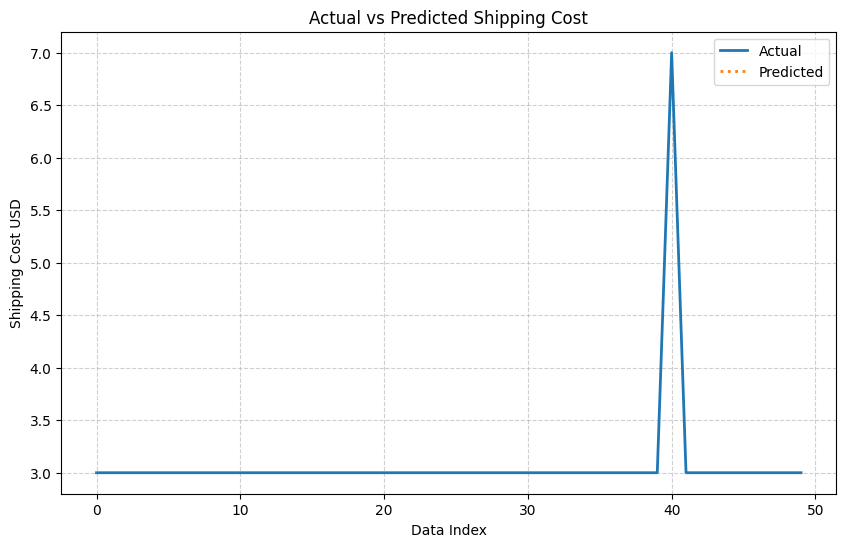

In [293]:
plt.figure(figsize=(10, 6))
plt.plot(y_test_actual[:50], label='Actual', linewidth=2)
plt.plot(y_pred[:50], label='Predicted', linestyle=':', linewidth=2)
plt.title('Actual vs Predicted Shipping Cost')
plt.xlabel('Data Index')
plt.ylabel('Shipping Cost USD')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**variabel ANN**

In [334]:
num_classes = len(np.unique(y_ann)) # Determine the number of unique classes

ann = Sequential()
ann.add(Dense(64, activation='relu', input_dim=X_train_ann_scaled.shape[1])) # Use scaled X_train_ann
ann.add(Dense(32, activation='relu'))
ann.add(Dense(16, activation='relu'))
ann.add(Dense(num_classes, activation='softmax')) # Output layer for multi-class classification

ann.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # Use sparse_categorical_crossentropy for integer labels
    metrics=['accuracy']
)

history = ann.fit(
    X_train_ann_scaled, # Use scaled X_train_ann
    y_train_ann,        # Use unscaled integer y_train_ann
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1989/1989 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9696 - loss: 0.1633 - val_accuracy: 0.9771 - val_loss: 0.0817
Epoch 2/20
1989/1989 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9816 - loss: 0.0606 - val_accuracy: 0.9816 - val_loss: 0.0496
Epoch 3/20
1989/1989 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9839 - loss: 0.0455 - val_accuracy: 0.9845 - val_loss: 0.0402
Epoch 4/20
1989/1989 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9851 - loss: 0.0394 - val_accuracy: 0.9876 - val_loss: 0.0317
Epoch 5/20
1989/1989 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - accuracy: 0.9863 - loss: 0.0362 - val_accuracy: 0.9869 - val_loss: 0.0319
Epoch 6/20
1989/1989 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9871 - loss: 0.0338 - val_accuracy: 0.9883 - val_loss: 0.0300
Epoch 7/20
1989/1989 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9875 - loss: 0.0323 - val_accuracy: 0.9884 - val_loss: 0.0286
Epoch 8/20
1989/1989 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9881 - loss: 0.0305 - val_accur

**Evaluation ANN Classification**

In [375]:
print("=== ANN Evaluation Results ===")

=== ANN Evaluation Results ===


**Tabel Perbandingan Model**

In [378]:
comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'K-NN', 'ANN'],
    'Accuracy': [
        dt_accuracy,
        knn_accuracy,
        ann_accuracy
    ]
})

comparison

,Model,Accuracy
0,Decision Tree,0.987279
1,K-NN,0.981296
2,ANN,0.986324


In [380]:
comparison = pd.DataFrame({
    'Model': ['Decision Tree', 'K-NN', 'ANN'],
    'Accuracy': [dt_accuracy, knn_accuracy, ann_accuracy]
})

comparison

,Model,Accuracy
0,Decision Tree,0.987279
1,K-NN,0.981296
2,ANN,0.986324


**Model Terbaik**

In [385]:
best_model = comparison.loc[
    comparison['Accuracy'].idxmax(),
    'Model'
]

best_accuracy = comparison['Accuracy'].max()

print("===== HASIL PERBANDINGAN MODEL =====")
print(comparison)

print("\nModel Terbaik :", best_model)
print("Accuracy      :", round(best_accuracy,4))

===== HASIL PERBANDINGAN MODEL =====
           Model  Accuracy
0  Decision Tree  0.987279
1           K-NN  0.981296
2            ANN  0.986324

Model Terbaik : Decision Tree
Accuracy      : 0.9873


**Visualisasi Perbandingan Accuracy**

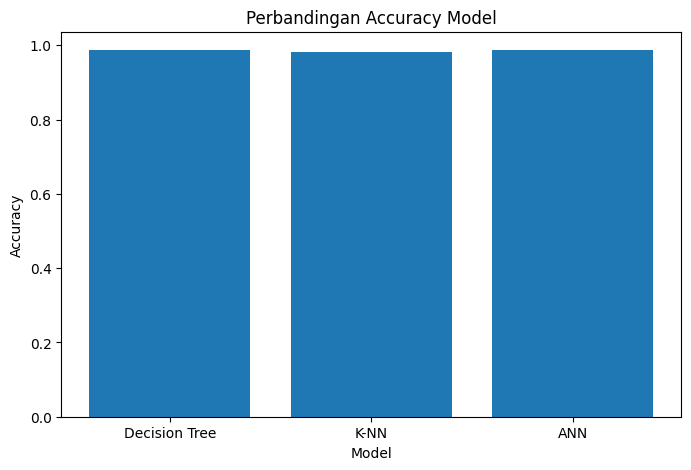

In [386]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    comparison['Model'],
    comparison['Accuracy']
)

plt.title('Perbandingan Accuracy Model')
plt.xlabel('Model')
plt.ylabel('Accuracy')

plt.show()

**Visualisasi Semua Metrik Sekaligus**

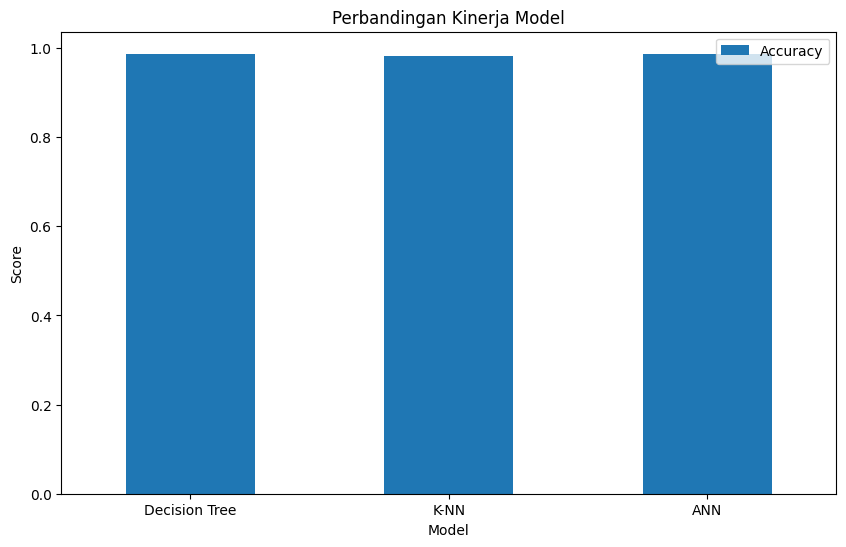

In [387]:
comparison.set_index('Model').plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('Perbandingan Kinerja Model')
plt.ylabel('Score')
plt.xticks(rotation=0)

plt.show()

**Kesimpulan**

In [388]:
print("KESIMPULAN")
print(f"Akurasi Decision Tree : {dt_accuracy:.4f}")
print(f"Akurasi K-NN          : {knn_accuracy:.4f}")
print(f"Akurasi ANN           : {ann_accuracy:.4f}")

accuracies = {
    'Decision Tree': dt_accuracy,
    'K-NN': knn_accuracy,
    'ANN': ann_accuracy
}

best_model_name = max(accuracies, key=accuracies.get)
best_accuracy_value = accuracies[best_model_name]

print(f"\nModel terbaik adalah {best_model_name}.")
print(f"Accuracy      : {best_accuracy_value:.4f}")

print("\nModel terbaik dipilih berdasarkan nilai akurasi tertinggi pada data testing.")

KESIMPULAN
Akurasi Decision Tree : 0.9873
Akurasi K-NN          : 0.9813
Akurasi ANN           : 0.9863

Model terbaik adalah Decision Tree.
Accuracy      : 0.9873

Model terbaik dipilih berdasarkan nilai akurasi tertinggi pada data testing.
